# K-Means Popularity Ablation Study

Goal: Compare clustering behavior in two setups:
1. Baseline: keep all engineered features (including popularity and members)
2. Ablation: remove popularity-driven signals (`popularity`, `members`) from clustering features

This helps verify whether clusters are mainly popularity-driven or still meaningful without those features.

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_utils import load_raw_tables
from src.preprocessing import prepare_kmeans_features
from src.clustering import train_cluster_and_save

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

In [2]:
base_dir = Path.cwd()
data = load_raw_tables(start_dir=base_dir)
animes = data["animes"]
profiles = data["profiles"]
reviews = data["reviews"]

X_all, analysis_df, meta = prepare_kmeans_features(animes, profiles, reviews)

print("Feature matrix shape:", X_all.shape)
print("Columns include members?", "members" in X_all.columns)
print("Columns include popularity?", "popularity" in X_all.columns)
display(X_all.head(3))

Feature matrix shape: (19311, 10)
Columns include members? True
Columns include popularity? True


,episodes,members,popularity,aired_year,genre_count,title_len,synopsis_len,favorites_count,review_count,review_text_len_mean
0,25.0,489888,141,2015.0,5.0,23.0,1041.0,513.0,104.0,3875.288462
1,22.0,995473,28,2014.0,5.0,23.0,838.0,2971.0,40.0,6055.750000
2,13.0,581663,98,2017.0,5.0,13.0,1214.0,1571.0,610.0,3563.455738


In [3]:
def run_experiment(name, X_input):
    artifacts_dir = base_dir / "artifacts" / name
    output = train_cluster_and_save(X=X_input, analysis_df=analysis_df, artifacts_dir=artifacts_dir)
    summary = {
        "experiment": name,
        "rows": len(X_input),
        "features": X_input.shape[1],
        "best_k": output["best_k"],
        "train_silhouette": output["metadata"]["train_silhouette"],
        "test_silhouette": output["metadata"]["test_silhouette"],
        "silhouette_gap": output["metadata"]["silhouette_gap"],
        "artifacts_dir": str(artifacts_dir),
    }
    return output, summary

In [4]:
# Experiment A: baseline with all features.
out_with_pop, summary_with_pop = run_experiment("with_popularity", X_all)

# Experiment B: remove popularity-heavy signals from clustering inputs.
drop_cols = [c for c in ["members", "popularity"] if c in X_all.columns]
X_without_pop = X_all.drop(columns=drop_cols, errors="ignore").copy()
out_without_pop, summary_without_pop = run_experiment("without_popularity", X_without_pop)

print("Dropped in ablation experiment:", drop_cols)

Dropped in ablation experiment: ['members', 'popularity']


In [5]:
comparison = pd.DataFrame([summary_with_pop, summary_without_pop])
display(comparison)

,experiment,rows,features,best_k,train_silhouette,test_silhouette,silhouette_gap,artifacts_dir
0,with_popularity,19311,10,2,0.676421,0.664817,0.011604,c:\Users\yasho\Downloads\Entertainment-Rating-...
1,without_popularity,19311,8,2,0.718233,0.698654,0.019579,c:\Users\yasho\Downloads\Entertainment-Rating-...


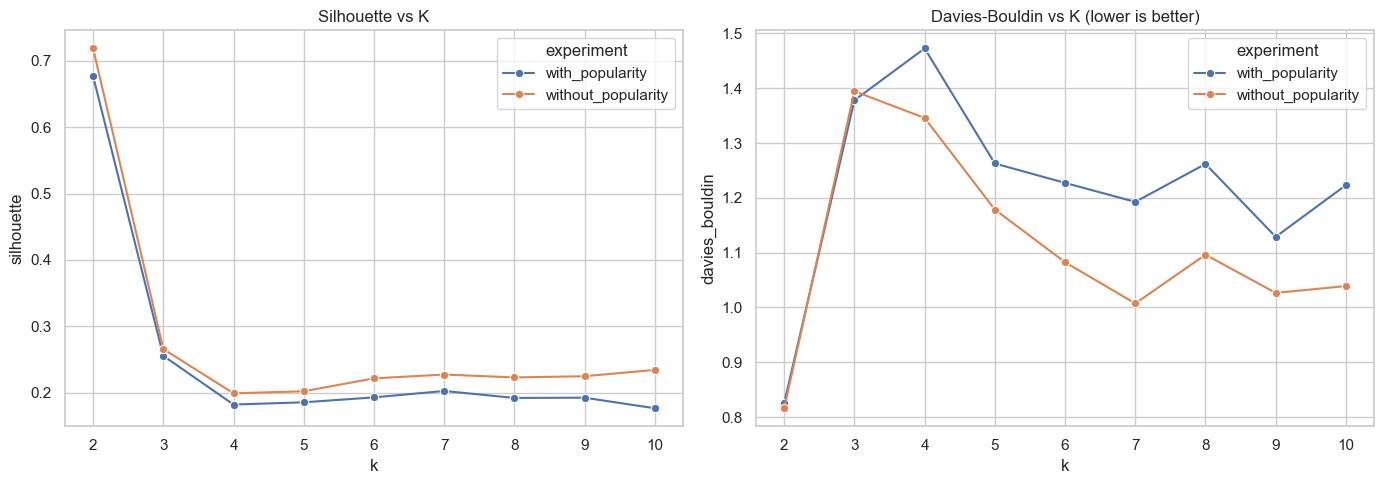

In [6]:
k1 = out_with_pop["k_eval"].copy()
k1["experiment"] = "with_popularity"
k2 = out_without_pop["k_eval"].copy()
k2["experiment"] = "without_popularity"
k_eval_both = pd.concat([k1, k2], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=k_eval_both, x="k", y="silhouette", hue="experiment", marker="o", ax=axes[0])
axes[0].set_title("Silhouette vs K")
sns.lineplot(data=k_eval_both, x="k", y="davies_bouldin", hue="experiment", marker="o", ax=axes[1])
axes[1].set_title("Davies-Bouldin vs K (lower is better)")
plt.tight_layout()
plt.show()

In [7]:
prof_a = out_with_pop["cluster_profile"].copy()
prof_a["experiment"] = "with_popularity"
prof_b = out_without_pop["cluster_profile"].copy()
prof_b["experiment"] = "without_popularity"
profile_both = pd.concat([prof_a, prof_b], ignore_index=True)

display(profile_both)
display(out_with_pop["cluster_meanings"])
display(out_without_pop["cluster_meanings"])

,cluster,cluster_size,score_mean,score_median,score_std,members_mean,members_median,popularity_mean,popularity_median,experiment
0,0,18913,6.397153,6.390,0.981212,22037.135092,2237.0,7879.611326,7699.0,with_popularity
1,1,398,8.230503,8.250,0.419166,637706.723618,547934.0,175.540201,112.5,with_popularity
2,0,268,8.287649,8.275,0.442484,688259.977612,634428.0,239.619403,86.5,without_popularity
3,1,19043,6.409232,6.400,0.988623,25528.642441,2280.0,7826.116473,7641.0,without_popularity


,cluster,cluster_label,reason
0,0,Long-tail / Lower Engagement,Lower members and broader long-tail catalog
1,1,Mainstream / High Engagement,High members and concentrated popularity


,cluster,cluster_label,reason
0,0,Mainstream / High Engagement,High members and concentrated popularity
1,1,Long-tail / Lower Engagement,Lower members and broader long-tail catalog


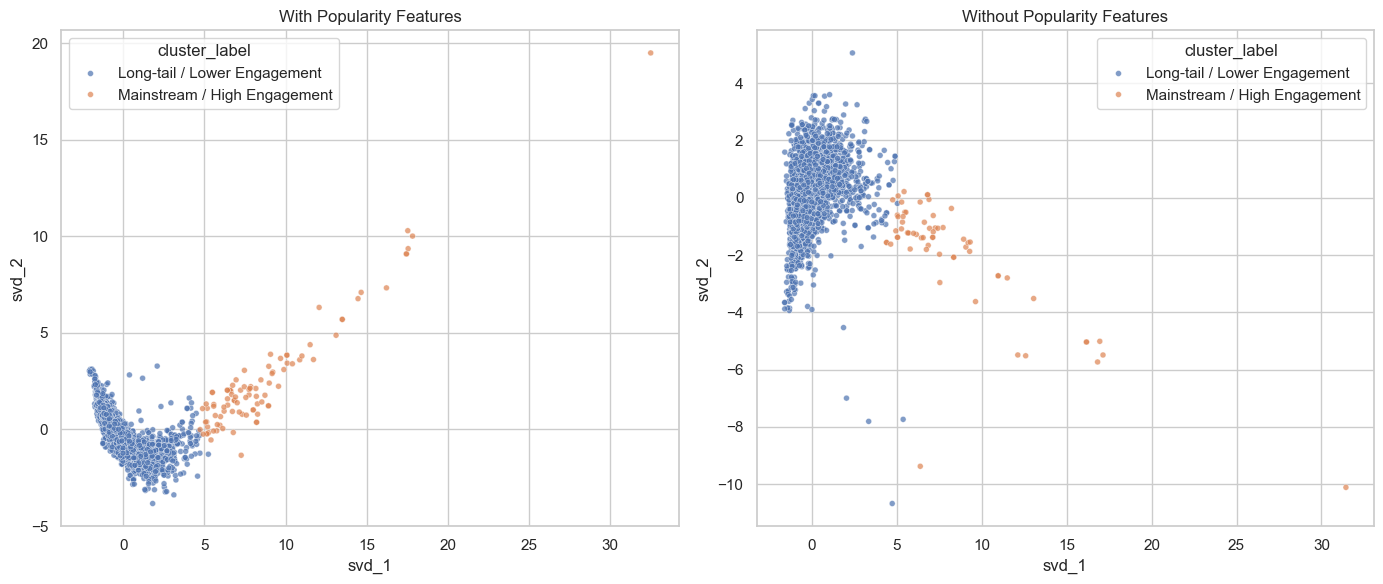

In [8]:
p1 = out_with_pop["cluster_projection"].copy()
p1["experiment"] = "with_popularity"
p2 = out_without_pop["cluster_projection"].copy()
p2["experiment"] = "without_popularity"

plot_a = p1.sample(min(4000, len(p1)), random_state=42)
plot_b = p2.sample(min(4000, len(p2)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=plot_a, x="svd_1", y="svd_2", hue="cluster_label", s=18, alpha=0.7, ax=axes[0])
axes[0].set_title("With Popularity Features")
sns.scatterplot(data=plot_b, x="svd_1", y="svd_2", hue="cluster_label", s=18, alpha=0.7, ax=axes[1])
axes[1].set_title("Without Popularity Features")
plt.tight_layout()
plt.show()

## How To Interpret Results

If clustering quality remains strong after removing `members` and `popularity`, your model is not only popularity-driven.
If quality drops sharply, popularity signals were carrying most of the separation.